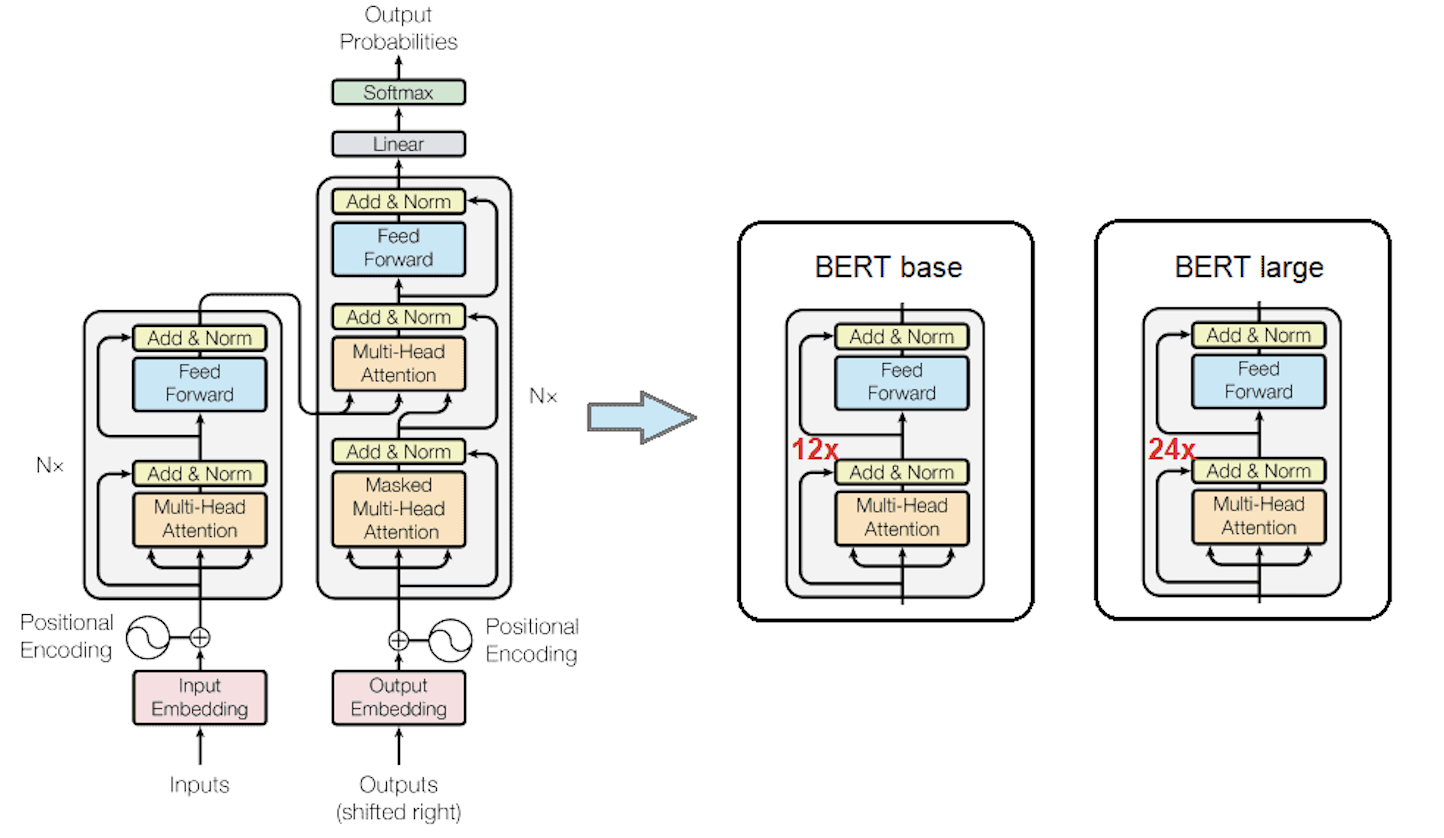

🚀 Project Introduction: BERT Implementation from Scratch
This project is a ground-up implementation of BERT (Bidirectional Encoder Representations from Transformers), crafted entirely from scratch using PyTorch. It reconstructs the core architecture of BERT—including token, segment, and positional embeddings, multi-head self-attention, and stacked transformer encoder layers—without relying on prebuilt models or high-level wrappers. Designed for clarity and modularity, the codebase offers a hands-on exploration of how BERT processes language context bidirectionally and builds rich token representations. Whether you're diving into NLP internals or benchmarking custom variants, this implementation serves as both a learning tool and a flexible foundation for experimentation.




In [1]:
import torch
import torch.nn as nn

In [2]:
class BERT_embedding(nn.Module):
    def __init__(self,
                 vocab_size,
                 n_segments,
                 max_len,
                 embed_dim,
                 dropout):
        super().__init__()
        self.token_embedding= nn.Embedding(vocab_size, embed_dim)
        self.segment_embedding= nn.Embedding(n_segments, embed_dim)
        self.position_embedding = nn.Embedding(max_len, embed_dim)

        self.drop = nn.Dropout(dropout)
        
        self.pos_inp = torch.tensor([i for i in range(max_len)],)

    def forward(self, seq, seg):
        embed_val = self.token_embedding(seq) + self.segment_embedding(seg) + self.position_embedding(self.pos_inp)
        embed_val = self.drop(embed_val)
        return embed_val

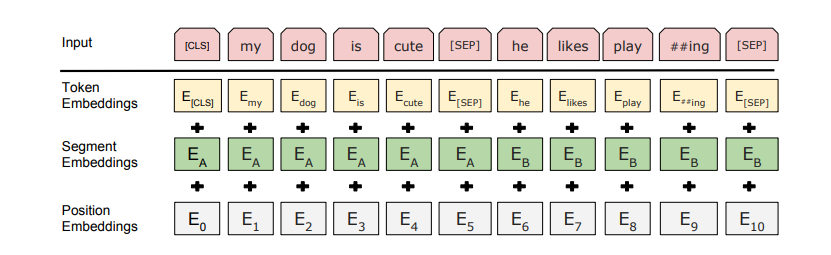



### 🧠 `[CLS]` — **Classification Token**
- **Purpose**: Added at the **start** of every input sequence.
- **Role**: Its final hidden state is used for **sequence-level tasks** like classification, sentiment analysis, or next sentence prediction.
- **Example**:  
  Input: `[CLS] The movie was excellent [SEP]`  
  Output: The embedding of `[CLS]` is passed to a classifier head.

---

### 🔗 `[SEP]` — **Separator Token**
- **Purpose**: Separates different segments in the input.
- **Role**: Used to distinguish between sentence A and sentence B in tasks like **Next Sentence Prediction** or **Question Answering**.
- **Example**:  
  Input: `[CLS] What is AI? [SEP] Artificial Intelligence is... [SEP]`  
  BERT uses segment embeddings to differentiate the two parts.

---

### 🎭 `[MASK]` — **Masked Token**
- **Purpose**: Used during **pretraining** for the Masked Language Modeling (MLM) task.
- **Role**: Random tokens are replaced with `[MASK]`, and BERT learns to predict them using context.
- **Example**:  
  Input: `[CLS] The [MASK] was excellent [SEP]`  
  Target: Predict `"movie"` from surrounding context.




My aim  is to create BERT Base Model:-
BERTBASE (L=12, H=768, A=12, Total Parameters=110M)

In [3]:
class BERT(nn.Module):
    def __init__(self,
                 vocab_size,
                 n_segments,
                 max_len,
                 embed_dim,
                 n_layers,
                 attn_heads,
                 dropout):
        super().__init__()
        self.embedding = BERT_embedding(vocab_size, n_segments, max_len, embed_dim, dropout)
        self.encoder_layer = nn.TransformerEncoderLayer(embed_dim, attn_heads, embed_dim*4)
        self.encoder_block = nn.TransformerEncoder(self.encoder_layer, n_layers)

    def forward(self, seq, seg):
        out = self.embedding(seq, seg)
        out = self.encoder_block(out)
        return out

In [4]:

if __name__ == "__main__":
    VOCAB_SIZE = 30000
    N_SEGMENTS = 3
    MAX_LEN = 512
    EMBED_DIM = 768
    N_LAYERS = 12
    ATTN_HEADS = 12
    DROPOUT = 0.1

    sample_seq = torch.randint(high=VOCAB_SIZE, size=[MAX_LEN,])
    sample_seg = torch.randint(high=N_SEGMENTS, size=[MAX_LEN,])

    embedding = BERT_embedding(VOCAB_SIZE, N_SEGMENTS, MAX_LEN, EMBED_DIM, DROPOUT)
    embedding_tensor = embedding(sample_seq, sample_seg)
    print(embedding_tensor.size())

    bert = BERT(VOCAB_SIZE, N_SEGMENTS, MAX_LEN, EMBED_DIM, N_LAYERS, ATTN_HEADS, DROPOUT)
    out = bert(sample_seq, sample_seg)
    print(out.size())

torch.Size([512, 768])


c:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\pro_env\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


torch.Size([512, 768])


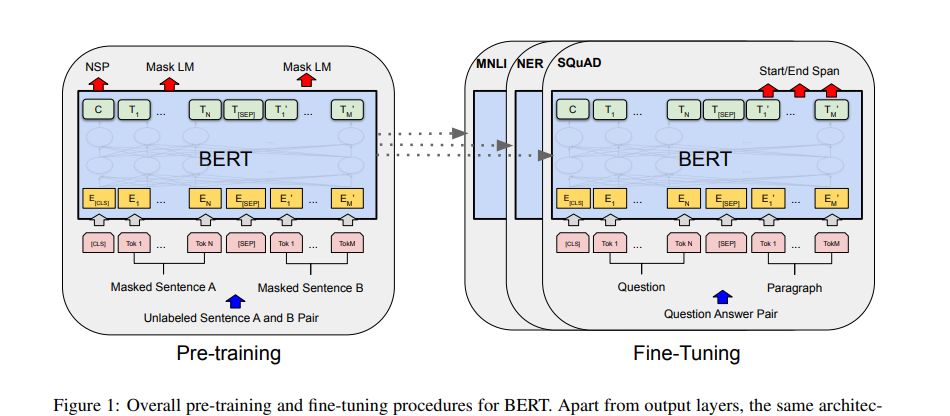

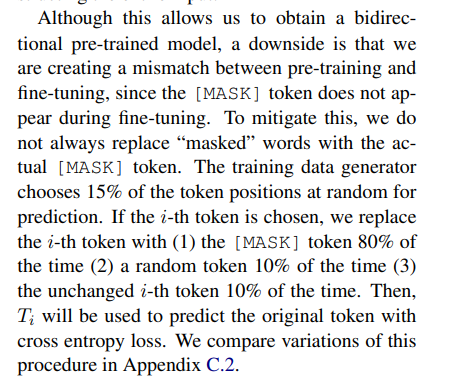



### ⚠️ Pretraining vs Fine-tuning Mismatch
- **Issue**: The `[MASK]` token is used during pretraining but **never appears during fine-tuning**, creating a distributional mismatch.
- **Impact**: The model may overfit to artificial masking patterns and underperform on real-world inputs.

---

### 🧠 Mitigation Strategy: Noisy Masking
To reduce this mismatch, BERT uses a **probabilistic masking scheme** during pretraining:

#### 🔍 Masking Procedure (applied to 15% of tokens):
1. **80% of the time** → Replace with `[MASK]`  
   _Example: “The movie was [MASK].”_
2. **10% of the time** → Replace with a **random token**  
   _Example: “The movie was banana.”_
3. **10% of the time** → Keep the **original token unchanged**  
   _Example: “The movie was great.”_

---

### 🎯 Objective
- The model is trained to **predict the original token** (`Ti`) at the masked position.
- **Loss Function**: Cross-entropy between predicted token distribution and the true token.

---

### ✅ Benefits
- Encourages the model to **generalize better** beyond the `[MASK]` token.
- Prevents over-reliance on artificial cues.
- Improves robustness during downstream fine-tuning.






---

### How It Works: A Step-by-Step Explanation

1.  **Get Output Vectors:** The input (question + context) is processed by the Transformer layers (the `Nx` block in your image). This produces a final output vector, $T_i$, for each input token. In the image, these are the `TK 1` through `TK 27` vectors. Each vector $T_i$ is a rich numerical representation of its corresponding token in context.

2.  **Find the Best Start Token:**
    * The model computes the **dot product** between the learned **start vector S** and every single token vector $T_i$.
    * The dot product, $S \cdot T_i$, gives a single number or a **"start score"**. This score represents how "start-like" that token is. A higher score means the model thinks it's a good candidate for the beginning of the answer.
    * These scores are then passed through a **softmax** function. This converts all the raw start scores into a probability distribution, where the sum of all probabilities is 1. The token with the highest probability is the model's best guess for the start of the answer.
    * In your image, the red arrow pointing to **TK 10** ("Shanghai") indicates that it received the highest start probability.

3.  **Find the Best End Token:**
    * Exactly the same process is repeated with the learned **end vector E**.
    * The model calculates the dot product $E \cdot T_i$ for every token vector to get an **"end score"**.
    * These end scores are also put through a softmax function to get end probabilities.

4.  **Identify the Best Answer Span:**
    * The model now has a start score and an end score for every token. To find the best overall answer span from a start position `i` to an end position `j`, it simply adds their raw scores:
        $$\text{Span Score}(i, j) = (\text{Start Score for token } i) + (\text{End Score for token } j)$$
        $$\text{Span Score}(i, j) = S \cdot T_i + E \cdot T_j$$
    * The model calculates this for every possible span (where the end must come after the start, $j \ge i$) and picks the span with the absolute highest score as the final answer.

---

### A Concrete Vector Example

Let's imagine the vector dimension `H` is just 4 (in reality it's much larger, like 768).

* Assume after training, the model learned a **start vector S** that is good at identifying proper nouns that answer "What...?" questions. Let's say:
    $S = [0.8, -0.5, 0.9, 0.2]$

* Now let's look at the output vectors ($T_i$) for a few tokens from the context "...**Shanghai** is a City...":
    * $T_{10}$ (**Shanghai**): $[0.9, -0.4, 0.8, 0.1]$  *(This vector is very similar to S)*
    * $T_{11}$ (**is**): $[-0.2, 0.7, -0.1, 0.6]$ *(This vector is very different from S)*

Let's calculate the **start scores** for these two tokens:

* **Start Score (Shanghai):**
    $S \cdot T_{10} = (0.8 \times 0.9) + (-0.5 \times -0.4) + (0.9 \times 0.8) + (0.2 \times 0.1)$
    $= 0.72 + 0.20 + 0.72 + 0.02 = \mathbf{1.66}$  **(High Score)**

* **Start Score (is):**
    $S \cdot T_{11} = (0.8 \times -0.2) + (-0.5 \times 0.7) + (0.9 \times -0.1) + (0.2 \times 0.6)$
    $= -0.16 - 0.35 - 0.09 + 0.12 = \mathbf{-0.48}$ **(Low Score)**

As you can see, because the vector for "Shanghai" is mathematically similar to the learned start vector `S`, it gets a much higher score. After doing this for all tokens, the softmax function would assign the highest probability to "Shanghai" being the start. The same logic applies to finding the end token with the end vector `E`. Finally, the span with the highest combined score is chosen.